In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('course_final.csv')
df.head()

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,...,start_year,age_raw,age_missing_original,age_invalid,age_cleaned,age_final,age,age_group,exam_flag,LoE_num
0,HarvardX/PH207x/2012_Fall,MHxPC130275857,1,1,1,0,United States,unknown,NaN,unknown,...,2012,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
1,HarvardX/CB22x/2013_Spring,MHxPC130539455,1,1,0,0,France,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
2,HarvardX/CB22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
3,HarvardX/ER22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
4,HarvardX/ER22x/2013_Spring,MHxPC130198098,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN


In [3]:
df_viewed = df[df["viewed"] == 1].copy()

explored_group = df_viewed[df_viewed["explored"] == 1]
non_explored_group = df_viewed[df_viewed["explored"] == 0]

print("Explored:", len(explored_group))
print("Not Explored:", len(non_explored_group))

Explored: 37584
Not Explored: 287777


In [4]:
from sklearn.metrics import roc_curve, precision_recall_curve

def find_thresholds(y_true, scores):
    
    # ROC
    fpr, tpr, roc_thresholds = roc_curve(y_true, scores)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    roc_best_threshold = roc_thresholds[best_idx]
    
    # PR
    precision, recall, pr_thresholds = precision_recall_curve(y_true, scores)
    f1 = (2 * precision * recall) / (precision + recall + 1e-9)
    best_idx_pr = np.argmax(f1)
    
    pr_best_threshold = pr_thresholds[best_idx_pr]
    
    return roc_best_threshold, pr_best_threshold

In [7]:
num_vars = ["nevents", "ndays_act", "nplay_video", "nforum_posts"]
threshold_vars = ["nevents", "ndays_act", "nplay_video"]

threshold_results = []

y = df_viewed["explored"]

for var in threshold_vars:
    x = df_viewed[var].fillna(0)
    roc_t, pr_t = find_thresholds(y, x)
    threshold_results.append({
        "variable": var,
        "roc_threshold": roc_t,
        "pr_threshold": pr_t
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,variable,roc_threshold,pr_threshold
0,nevents,712.0,1274.0
1,ndays_act,10.0,18.0
2,nplay_video,98.0,170.0


In [8]:
df_viewed[df_viewed["explored"] == 1]
df_viewed[df_viewed["explored"] == 0]

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,...,start_year,age_raw,age_missing_original,age_invalid,age_cleaned,age_final,age,age_group,exam_flag,LoE_num
1,HarvardX/CB22x/2013_Spring,MHxPC130539455,1,1,0,0,France,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
2,HarvardX/CB22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
3,HarvardX/ER22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
4,HarvardX/ER22x/2013_Spring,MHxPC130198098,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
5,HarvardX/CB22x/2013_Spring,MHxPC130024894,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
533982,MITx/6.00x/2013_Spring,MHxPC130137331,1,1,0,0,United States,Secondary,1992.0,m,...,2013,21.0,False,False,21.0,21.0,21.0,20s,0,2.0
533984,MITx/14.73x/2013_Spring,MHxPC130256541,1,1,0,0,United States,Master's,1982.0,m,...,2013,31.0,False,False,31.0,31.0,31.0,30s,0,4.0
533988,MITx/6.002x/2013_Spring,MHxPC130030805,1,1,0,0,Pakistan,Master's,1989.0,m,...,2013,24.0,False,False,24.0,24.0,24.0,20s,0,4.0
533989,MITx/6.00x/2013_Spring,MHxPC130184108,1,1,0,0,Canada,Bachelor's,1991.0,m,...,2013,22.0,False,False,22.0,22.0,22.0,20s,0,3.0


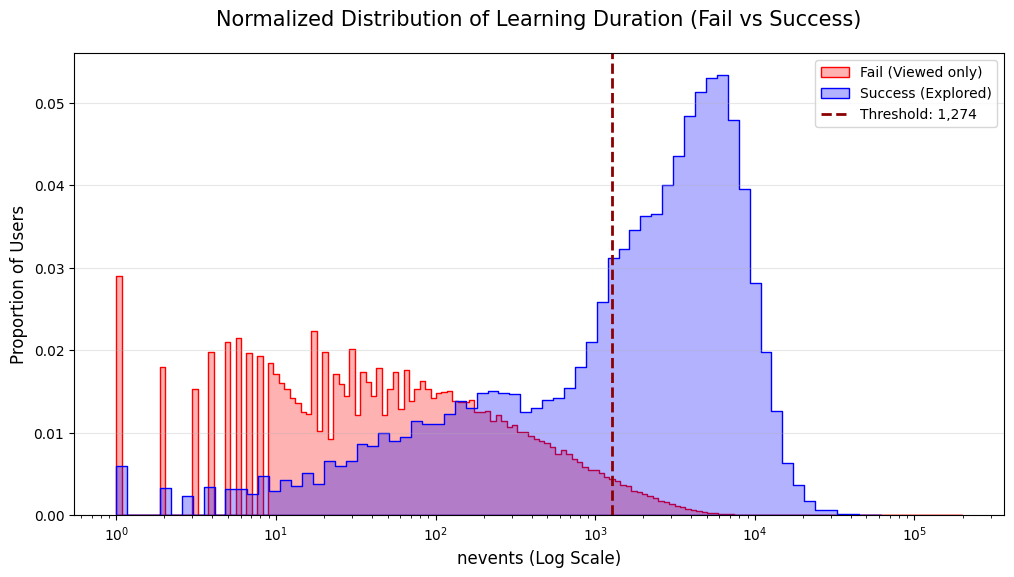

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

threshold = threshold_df.loc[0, 'pr_threshold']

plt.figure(figsize=(12, 6))

# 성공/실패 그룹의 비율(Proportion) 비교
# 포인트 1: log_scale=True 를 추가하면 자동으로 X축이 로그 스케일로 변환됩니다.
sns.histplot(data=non_explored_group, x='nevents', color='red', label='Fail (Viewed only)', 
             stat='proportion', common_norm=False, alpha=0.3, element="step",
             log_scale=True) 

sns.histplot(data=explored_group, x='nevents', color='blue', label='Success (Explored)', 
             stat='proportion', common_norm=False, alpha=0.3, element="step",
             log_scale=True)

# 포인트 2: 축 자체가 로그로 변환되었기 때문에, 임계값은 원래 숫자(threshold) 그대로 넣으면 알아서 제자리에 그어집니다!
# 팁: {threshold:,.0f} 를 쓰면 '1274'가 '1,274' 처럼 천 단위 콤마가 예쁘게 찍힙니다.
plt.axvline(threshold, color='darkred', linestyle='--', linewidth=2, 
            label=f'Threshold: {threshold:,.0f}')

# 그래프 디테일
plt.title('Normalized Distribution of Learning Duration (Fail vs Success)', fontsize=15, pad=20)
plt.xlabel('nevents (Log Scale)', fontsize=12) # 축 이름에 Log Scale을 명시해주면 완벽합니다.
plt.ylabel('Proportion of Users', fontsize=12) 
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

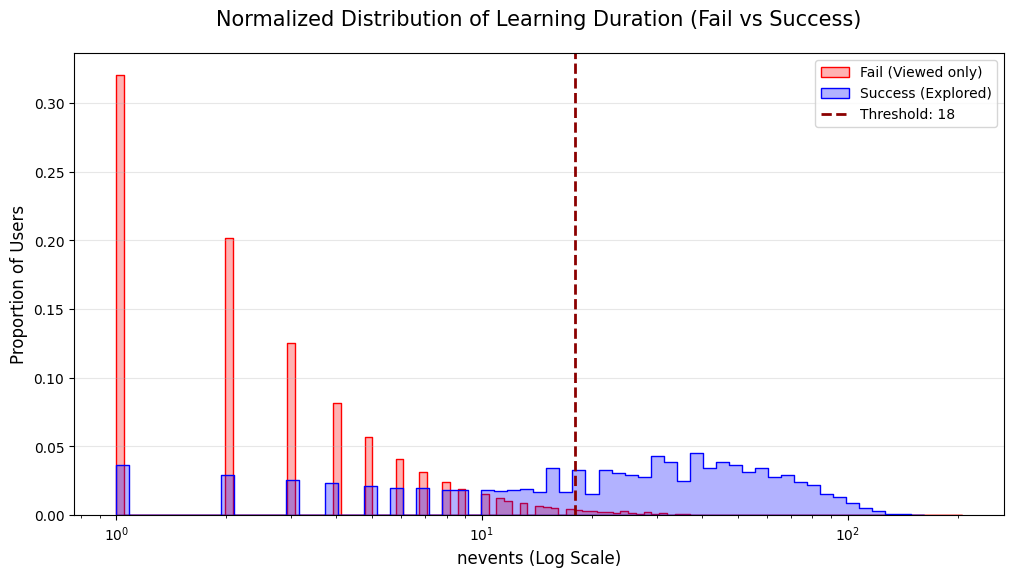

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

threshold = threshold_df.loc[1, 'pr_threshold']

plt.figure(figsize=(12, 6))

# 성공/실패 그룹의 비율(Proportion) 비교
# 포인트 1: log_scale=True 를 추가하면 자동으로 X축이 로그 스케일로 변환됩니다.
sns.histplot(data=non_explored_group, x='ndays_act', color='red', label='Fail (Viewed only)', 
             stat='proportion', common_norm=False, alpha=0.3, element="step",
             log_scale=True) 

sns.histplot(data=explored_group, x='ndays_act', color='blue', label='Success (Explored)', 
             stat='proportion', common_norm=False, alpha=0.3, element="step",
             log_scale=True)

# 포인트 2: 축 자체가 로그로 변환되었기 때문에, 임계값은 원래 숫자(threshold) 그대로 넣으면 알아서 제자리에 그어집니다!
# 팁: {threshold:,.0f} 를 쓰면 '1274'가 '1,274' 처럼 천 단위 콤마가 예쁘게 찍힙니다.
plt.axvline(threshold, color='darkred', linestyle='--', linewidth=2, 
            label=f'Threshold: {threshold:,.0f}')

# 그래프 디테일
plt.title('Normalized Distribution of Learning Duration (Fail vs Success)', fontsize=15, pad=20)
plt.xlabel('nevents (Log Scale)', fontsize=12) # 축 이름에 Log Scale을 명시해주면 완벽합니다.
plt.ylabel('Proportion of Users', fontsize=12) 
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

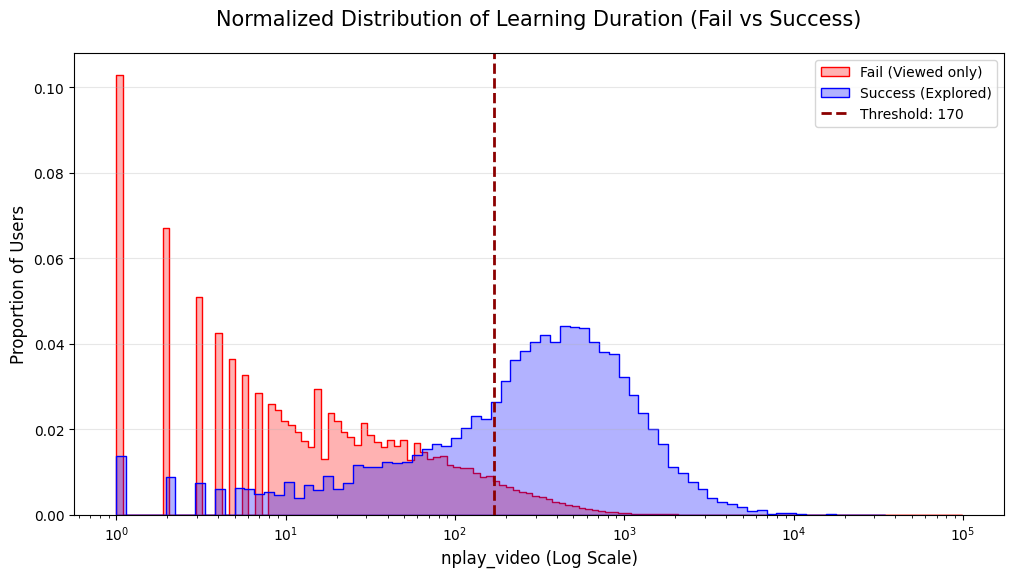

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

threshold = threshold_df.loc[2, 'pr_threshold']

plt.figure(figsize=(12, 6))

# 성공/실패 그룹의 비율(Proportion) 비교
# 포인트 1: log_scale=True 를 추가하면 자동으로 X축이 로그 스케일로 변환됩니다.
sns.histplot(data=non_explored_group, x='nplay_video', color='red', label='Fail (Viewed only)', 
             stat='proportion', common_norm=False, alpha=0.3, element="step",
             log_scale=True) 

sns.histplot(data=explored_group, x='nplay_video', color='blue', label='Success (Explored)', 
             stat='proportion', common_norm=False, alpha=0.3, element="step",
             log_scale=True)

# 포인트 2: 축 자체가 로그로 변환되었기 때문에, 임계값은 원래 숫자(threshold) 그대로 넣으면 알아서 제자리에 그어집니다!
# 팁: {threshold:,.0f} 를 쓰면 '1274'가 '1,274' 처럼 천 단위 콤마가 예쁘게 찍힙니다.
plt.axvline(threshold, color='darkred', linestyle='--', linewidth=2, 
            label=f'Threshold: {threshold:,.0f}')

# 그래프 디테일
plt.title('Normalized Distribution of Learning Duration (Fail vs Success)', fontsize=15, pad=20)
plt.xlabel('nplay_video (Log Scale)', fontsize=12) # 축 이름에 Log Scale을 명시해주면 완벽합니다.
plt.ylabel('Proportion of Users', fontsize=12) 
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()